Практика 18. Множинна лінійна регресія: відбір предикторів, інтерпретація коефіцієнтів, діагностика залишків
Студент: Войтович Богдан
Група: IT-32
Варіант 6 — Чернігів



In [13]:
import numpy as np
import pandas as pd

np.random.seed(6)
city = "Чернігів"
mean_temp = 8.0
amplitude = 13
hum_base = 75

rows = []
for month in range(1, 13):
    temp = mean_temp + amplitude * np.cos((month - 7) / 12 * 2 * np.pi) + np.random.normal(0, 1.0)
    humidity = hum_base + np.random.normal(0, 5.0)
    if temp < 8:
        opal_days = 30
    elif temp < 12:
        opal_days = 15
    else:
        opal_days = 0
    cost = 200 - 9.0 * temp + 0.6 * humidity + 2.5 * opal_days + np.random.normal(0, 15)
    rows.append({
        "місто": city,
        "місяць": month,
        "температура": round(temp, 1),
        "вологість": round(humidity, 1),
        "опалювальні_дні": opal_days,
        "витрати_на_опалення": round(cost, 1),
    })

heating = pd.DataFrame(rows)


In [14]:
import statsmodels.api as sm

X = heating[["температура", "вологість"]]
X = sm.add_constant(X)
y = heating["витрати_на_опалення"]

model_2vars = sm.OLS(y, X).fit()
print(model_2vars.summary())


                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.980
Model:                             OLS   Adj. R-squared:                  0.976
Method:                  Least Squares   F-statistic:                     222.5
Date:                 Thu, 17 Sep 2026   Prob (F-statistic):           2.18e-08
Time:                         18:36:29   Log-Likelihood:                -51.154
No. Observations:                   12   AIC:                             108.3
Df Residuals:                        9   BIC:                             109.8
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         273.4502     61.726      4

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Прогнозори"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


    Прогнозори       VIF
0        const  1.000000
1  температура  1.039927
2    вологість  1.039927


In [16]:
X3 = heating[["температура", "вологість", "опалювальні_дні"]]
X3 = sm.add_constant(X3)
model_3vars = sm.OLS(y, X3).fit()
print(model_3vars.summary())

print(f"R² двох предикторів: {model_2vars.rsquared:.3f}")
print(f"Adjusted R² двох предикторів: {model_2vars.rsquared_adj:.3f}")
print(f"R² трьох предикторів: {model_3vars.rsquared:.3f}")
print(f"Adjusted R² трьох предикторів: {model_3vars.rsquared_adj:.3f}")


                             OLS Regression Results                            
Dep. Variable:     витрати_на_опалення   R-squared:                       0.996
Model:                             OLS   Adj. R-squared:                  0.994
Method:                  Least Squares   F-statistic:                     611.7
Date:                 Thu, 17 Sep 2026   Prob (F-statistic):           8.72e-10
Time:                         18:36:35   Log-Likelihood:                -42.039
No. Observations:                   12   AIC:                             92.08
Df Residuals:                        8   BIC:                             94.02
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             236.1077     3

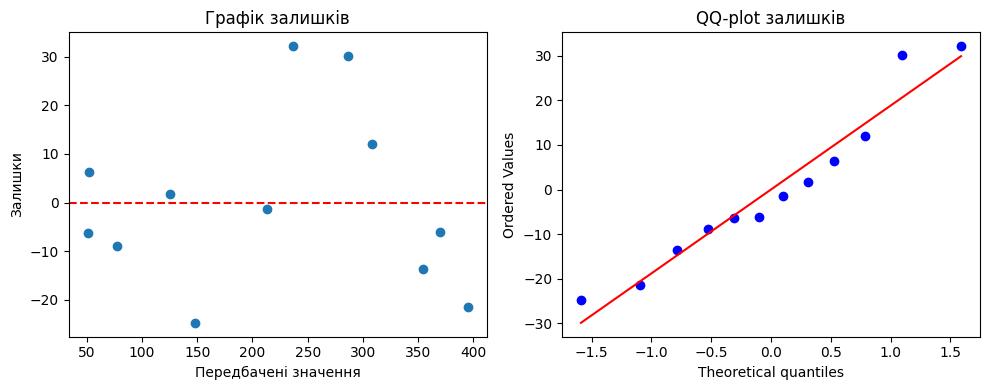

Шапіро-Вілк тест: stat=0.936, p=0.451
Залишки нормальні (H0 не відхиляємо).


In [17]:
import matplotlib.pyplot as plt
from scipy.stats import probplot, shapiro

residuals = model_2vars.resid
fitted = model_2vars.fittedvalues

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Передбачені значення")
plt.ylabel("Залишки")
plt.title("Графік залишків")

plt.subplot(1,2,2)
probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot залишків")

plt.tight_layout()
plt.show()

stat, pval = shapiro(residuals)
print(f"Шапіро-Вілк тест: stat={stat:.3f}, p={pval:.3f}")
if pval > 0.05:
    print("Залишки нормальні (H0 не відхиляємо).")
else:
    print("Відхиляємо нормальність залишків (H0 відхиляємо).")


In [18]:
X_simple = heating[["температура"]]
X_simple = sm.add_constant(X_simple)
model_simple = sm.OLS(y, X_simple).fit()

print(f"R² простої регресії: {model_simple.rsquared:.3f}")
print(f"Adjusted R² множинної регресії: {model_2vars.rsquared_adj:.3f}")


R² простої регресії: 0.979
Adjusted R² множинної регресії: 0.976


Контрольні питання
Чому sm.add_constant() є обов’язковим перед викликом sm.OLS(), і що станеться, якщо його пропустити?
Чим коефіцієнт множинної регресії відрізняється від коефіцієнта простої регресії з тим самим предиктором?
Чому звичайний R² не зменшується при додаванні будь-якого нового предиктора, навіть нерелевантного, і чому це робить його непридатним для порівняння моделей з різною кількістю предикторів?
Що означає VIF близький до 1, і що означає VIF вище 10, та які дії варто вживати при високому VIF?
Як аналіз залишків (графік проти передбачених значень, QQ-plot, тест Шапіро-Вілка) допомагає оцінити адекватність моделі?